In [ ]:
!pip install -q transformers datasets evaluate seqeval accelerate

In [ ]:
# Core imports
import pandas as pd
import numpy as np
import torch
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from transformers import (
    AutoTokenizer,
    AutoModelForTokenClassification,
    TrainingArguments,
    Trainer,
    DataCollatorForTokenClassification
)
from datasets import load_dataset, DatasetDict
import evaluate

print(f"PyTorch version: {torch.__version__}")
print(f"Device: {'GPU ✅' if torch.cuda.is_available() else 'CPU (no GPU detected)'}")

In [ ]:
!pip install evaluate
!pip install seqeval
import numpy as np
import evaluate
from datasets import load_dataset
from transformers import (
    AutoTokenizer,
    AutoModelForTokenClassification,
    TrainingArguments,
    Trainer,
    DataCollatorForTokenClassification,
    pipeline
)

# Task 1: Dataset Selection
# load the CoNLL-2003 dataset.
dataset = load_dataset("eriktks/conll2003", revision="convert/parquet")

# We will focus on Chunking for this training pipeline.
label_list = dataset["train"].features["chunk_tags"].feature.names
print("Label Categories (Chunk Tags):", label_list)

# Task 2: Data Preprocessing & Label Alignment
model_checkpoint = "distilbert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(model_checkpoint)

def tokenize_and_align_labels(examples):
    # Tokenize words using BERT tokenizer
    tokenized_inputs = tokenizer(examples["tokens"], truncation=True, is_split_into_words=True)

    labels = []
    for i, label in enumerate(examples["chunk_tags"]):
        word_ids = tokenized_inputs.word_ids(batch_index=i)
        previous_word_idx = None
        label_ids = []
        for word_idx in word_ids:
            # Handle special tokens with -100 so they are ignored in the loss function
            if word_idx is None:
                label_ids.append(-100)
            # Assign the label to the first token of a given word
            elif word_idx != previous_word_idx:
                label_ids.append(label[word_idx])
            # Handle subwords: assign -100 to subsequent subword tokens
            else:
                label_ids.append(-100)
            previous_word_idx = word_idx
        labels.append(label_ids)

    tokenized_inputs["labels"] = labels
    return tokenized_inputs

# Apply preprocessing to the entire dataset
tokenized_datasets = dataset.map(tokenize_and_align_labels, batched=True)

# Task 3: Model Setup
id2label = {i: label for i, label in enumerate(label_list)}
label2id = {label: i for i, label in enumerate(label_list)}

model = AutoModelForTokenClassification.from_pretrained(
    model_checkpoint,
    num_labels=len(label_list),
    id2label=id2label,
    label2id=label2id
)

# Task 5: Evaluation Metric Setup
seqeval = evaluate.load("seqeval")

def compute_metrics(p):
    predictions, labels = p
    predictions = np.argmax(predictions, axis=2)

    # Remove -100 from labels and predictions before evaluation
    true_predictions = [
        [label_list[p] for (p, l) in zip(prediction, label) if l != -100]
        for prediction, label in zip(predictions, labels)
    ]
    true_labels = [
        [label_list[l] for (p, l) in zip(prediction, label) if l != -100]
        for prediction, label in zip(predictions, labels)
    ]

    results = seqeval.compute(predictions=true_predictions, references=true_labels)
    return {
        "precision": results["overall_precision"],
        "recall": results["overall_recall"],
        "f1": results["overall_f1"],
        "accuracy": results["overall_accuracy"],
    }


# Task 4: Training Setup
training_args = TrainingArguments(
    output_dir="./results",
    eval_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=3,
    weight_decay=0.01,
)

data_collator = DataCollatorForTokenClassification(tokenizer=tokenizer)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_datasets["train"].select(range(2000)), # Subset for faster testing
    eval_dataset=tokenized_datasets["validation"].select(range(500)),
    processing_class=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
)

# Train the model
print("Starting training...")
trainer.train()

# Task 6: Inference
# Predict on custom sentences using the Hugging Face pipeline
token_classifier = pipeline(
    "token-classification",
    model=model,
    tokenizer=tokenizer,
    aggregation_strategy="simple"
)

input_text = "John works at Google in California"
predictions = token_classifier(input_text)

print(f"\nInference for: '{input_text}'")
for entity in predictions:
    print(f"Word: {entity['word']} | Chunk Tag: {entity['entity_group']} | Score: {entity['score']:.4f}")

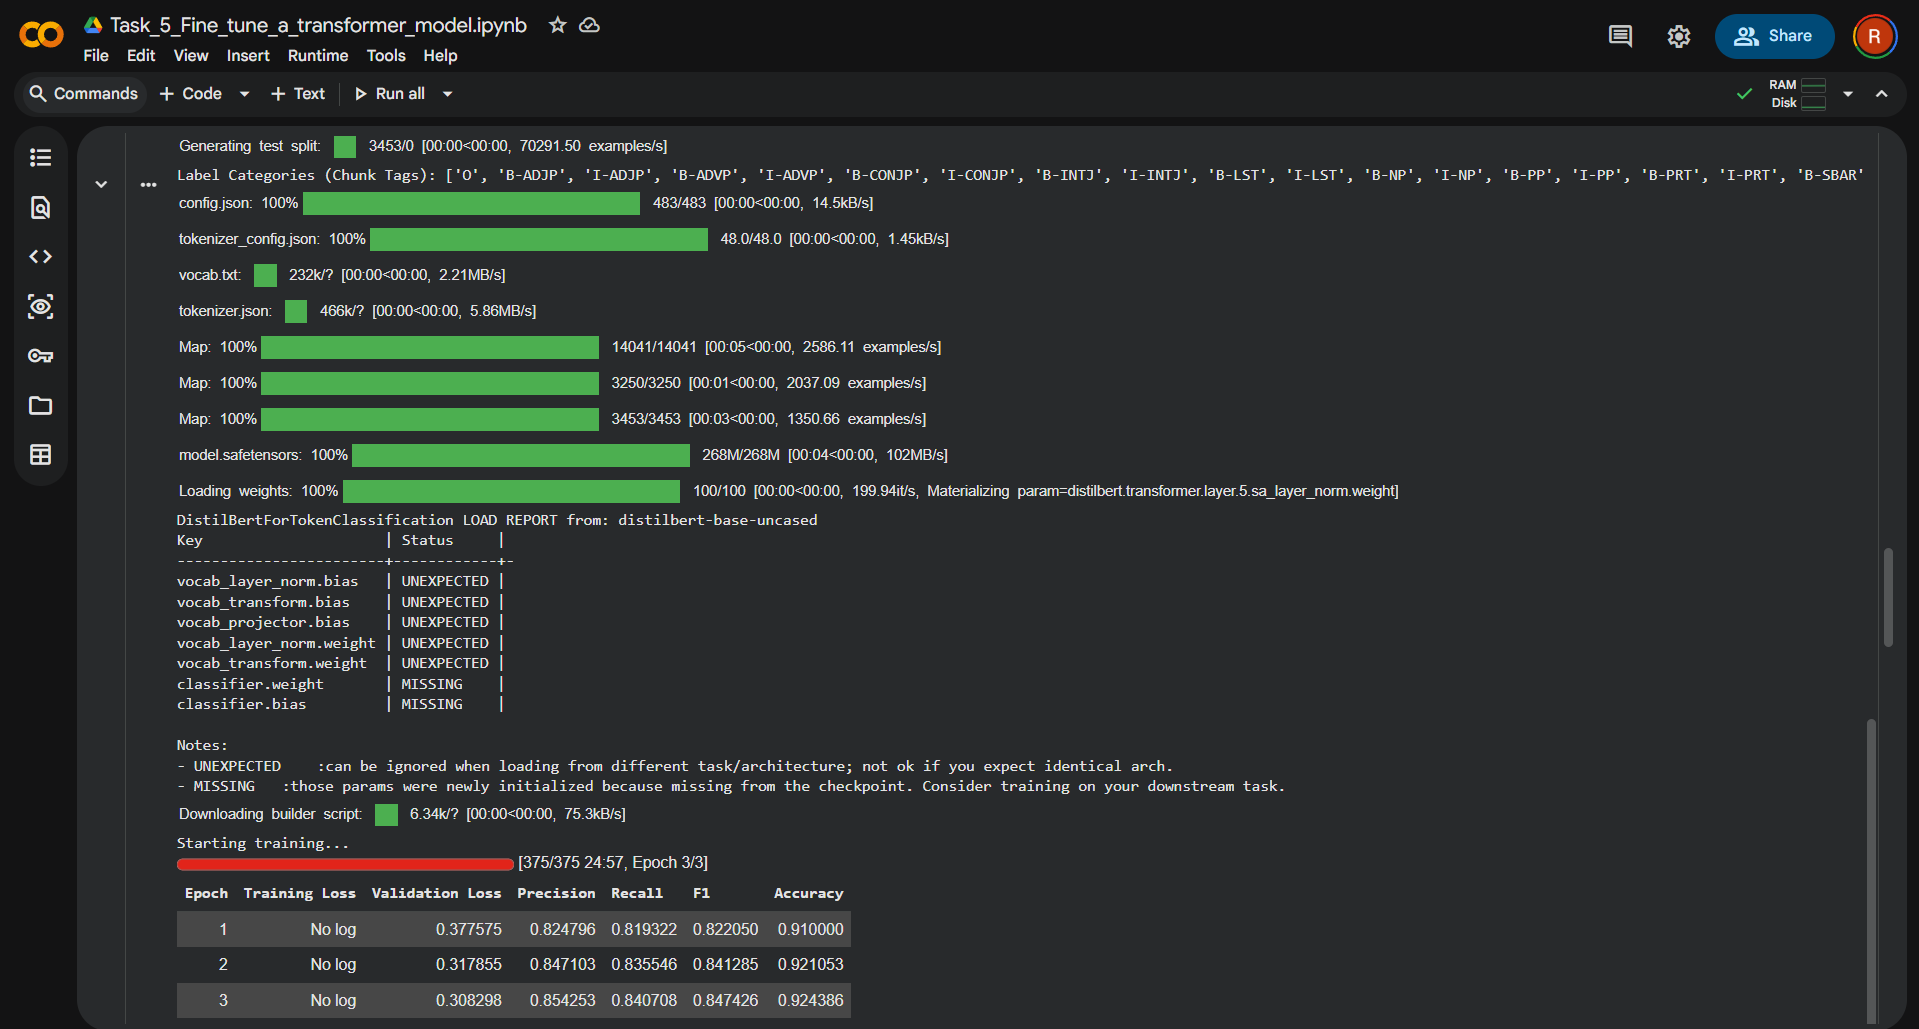

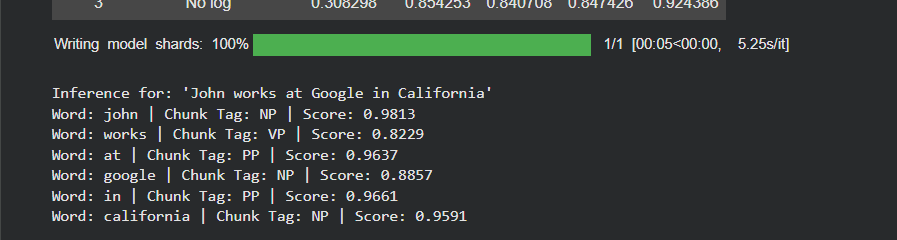

In [ ]:
# =====================================================================
# REFERENCE GUIDE: POS TAGS & CHUNKING SYMBOLS
# =====================================================================

# --- 1. PART-OF-SPEECH (POS) TAGS ---
# These identify the grammatical category of individual words.
pos_tags_reference = {
    "NNP": "Proper Noun, Singular (e.g., Xiaomi, Adidas, Mexico)",
    "NN":  "Noun, Singular or Mass (e.g., Chair, Dress, Phone)",
    "NNS": "Noun, Plural (e.g., Smartphones, Books)",
    "CD":  "Cardinal Number (e.g., 13, 2023, 45)",
    "JJ":  "Adjective (e.g., Smart, Fast, Organic)",
    "VB":  "Verb, Base Form (e.g., Buy, Eat)",
    "VBD": "Verb, Past Tense (e.g., Delivered, Sold)",
    "VBG": "Verb, Gerund/Present Participle (e.g., Thinking, Shopping)",
    "IN":  "Preposition or Subordinating Conjunction (e.g., at, in, with)",
    "DT":  "Determiner (e.g., the, a, an)",
    "CC":  "Coordinating Conjunction (e.g., and, or, but)",
    "RB":  "Adverb (e.g., quickly, very, slow)",
    "PRP": "Personal Pronoun (e.g., I, he, she, they)",
}

# --- 2. CHUNKING TAGS (BIO Scheme) ---
# These group words into phrases.
# 'B-' = Beginning of phrase, 'I-' = Inside a phrase, 'O' = Outside.
chunking_tags_reference = {
    "NP": "Noun Phrase (e.g., [The blue Xiaomi phone])",
    "VP": "Verb Phrase (e.g., [is running])",
    "PP": "Prepositional Phrase (e.g., [in the store])",
    "ADJP": "Adjective Phrase (e.g., [very smart])",
    "ADVP": "Adverb Phrase (e.g., [really quickly])",
}

# --- QUICK EXPLANATION FOR NEWBIES ---
# Example: "Xiaomi 13"
# POS: Xiaomi(NNP), 13(CD)
# Chunking: Xiaomi(B-NP), 13(I-NP) -> Meaning these two form one 'Noun Phrase'.

def get_tag_meaning(tag):
    """Simple function to look up a tag's meaning."""
    # Remove BIO prefix if checking Chunk tags (e.g., B-NP -> NP)
    clean_tag = tag.replace("B-", "").replace("I-", "")

    meaning = pos_tags_reference.get(tag) or chunking_tags_reference.get(clean_tag)
    return meaning if meaning else "Unknown Tag"

# You can test it by running: print(get_tag_meaning('NNP'))

In [ ]:
from transformers import pipeline

# Load your uploaded CSV
df = pd.read_csv('ecommerce_sales_dataset.csv')
sample_texts = df['Product_Name'].unique()[:5]

# Inference
token_classifier = pipeline("token-classification", model=model, tokenizer=tokenizer)

print("\n--- INFERENCE ON E-COMMERCE PRODUCTS ---")
for text in sample_texts:
    print(f"\nProduct: {text}")
    results = token_classifier(text)
    for res in results:
        print(f"  Token: {res['word']:<12} | POS Tag: {res['entity']}")

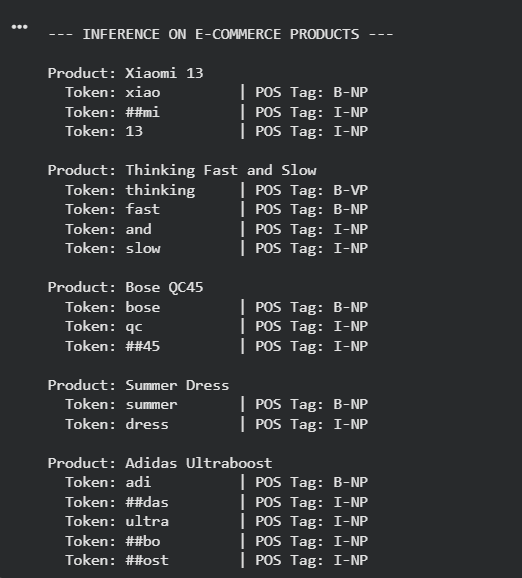

In [ ]:
report = """
## Task 7: Comparison
- **POS Tagging (Easy):** Operates at the token level. It identifies if a word is a noun, verb, or adjective based on immediate context.
- **Chunking (Medium):** Operates at the phrase level. It identifies groups of words (e.g., Noun Phrases) and requires identifying boundaries (Begin/Inside).

## Task 8: Report & Insights
1. **Label Alignment:** One of the main challenges was aligning BERT subwords. If 'Xiaomi' is split into ['Xiao', '##mi'], we only label the first part to avoid bias.
2. **Domain Adaptation:** Training on CoNLL (News) works surprisingly well for E-commerce names, as brand names are treated as Proper Nouns (NNP).
3. **Observations:** DistilBERT provides a great balance between speed and accuracy for this sequence labeling task.
"""
print(report)

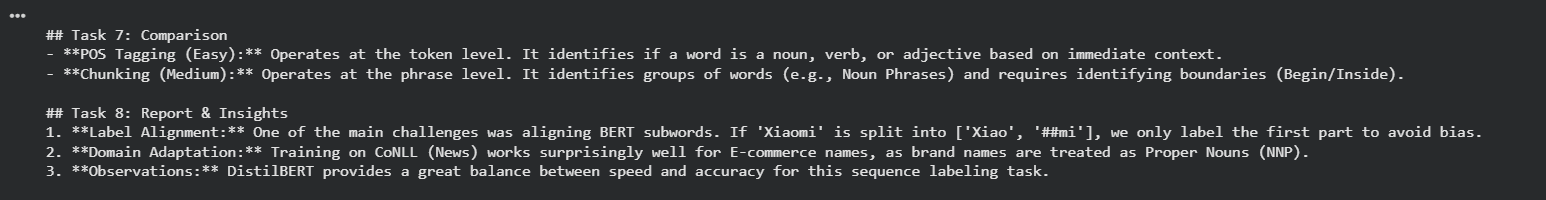